# 最简 DAS 数据读取与温和预处理基线

这个 notebook 只保留后续实验必须依赖的东西：

1. 按 `NAME` 从 `DATA_DIR/Airtag` 的时间范围选择并抽取 `DATA_DIR/DAS` 里的 TDMS；如果 `output/name_signals/{NAME}.csv` 已经存在，就直接复用。
2. 只读取前 `100` 个 DAS 通道。
3. 按论文思想丢弃靠近 interrogator 的前 `10 m`；同时保留你之前指出的“前 15 个通道噪声大”的配置，默认最终分析通道从 `15` 开始。
4. 只做非常温和的可选 `0.1 Hz` 高通，不做 MAD 归一化、不做自动频带选择、不做检测、不做 backprojection。

后续所有检测、定位、速度估计都应该从这个干净基线继续加。


In [135]:
from pathlib import Path
import csv
import math
import re
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180
plt.rcParams["axes.unicode_minus"] = False

# ===== 路径与名字 =====
PROJECT_ROOT = Path.cwd()
DATA_DIR = Path(r"D:\WeaklySupervisedFootstep\Data")
AIRTAG_DIR = DATA_DIR / "Airtag"
TDMS_DIR = DATA_DIR / "DAS"
SIGNAL_OUTPUT_DIR = PROJECT_ROOT / "output" / "name_signals"
FIBER_PATH_FILE = PROJECT_ROOT / "FiberPath"

NAME = "aipumin"
OVERWRITE_CSV = False

# ===== DAS 基本约定 =====
DAS_FS = 2000.0
CSV_UTC_OFFSET_HOURS = 8.0
ACTIVE_CHANNEL_COUNT = 100
CHANNEL_LENGTH_M = 1.0

# ===== 最简通道选择 =====
# 论文丢弃前 10 m；你的数据里前 15 通道噪声较大。
# 为了后续分析干净，默认最终使用 max(10m, 15ch) 之后的通道。
DROP_FIRST_METERS = 10.0
NOISY_PREFIX_CHANNELS = 15
DROP_FIRST_CHANNELS = int(round(DROP_FIRST_METERS / CHANNEL_LENGTH_M))
ANALYSIS_START_CHANNEL = max(DROP_FIRST_CHANNELS, NOISY_PREFIX_CHANNELS)

# ===== 温和预处理 =====
APPLY_HIGHPASS = True
HIGHPASS_HZ = 0.1
HIGHPASS_ORDER = 2

# 只影响画图，不改变 X_RAW / X_BASELINE。
DISPLAY_MAX_SAMPLES = 30000

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"DATA_DIR     = {DATA_DIR}")
print(f"NAME         = {NAME}")
print(f"Use first {ACTIVE_CHANNEL_COUNT} channels; analysis starts at channel {ANALYSIS_START_CHANNEL}.")


PROJECT_ROOT = d:\DAS2Steps
DATA_DIR     = D:\WeaklySupervisedFootstep\Data
NAME         = aipumin
Use first 100 channels; analysis starts at channel 15.


## 1. 光纤路径与通道位置

`FiberPath` 是二维定位的几何基准。这里不做任何拟合或平移，只按路径长度把通道映射到光纤折线。


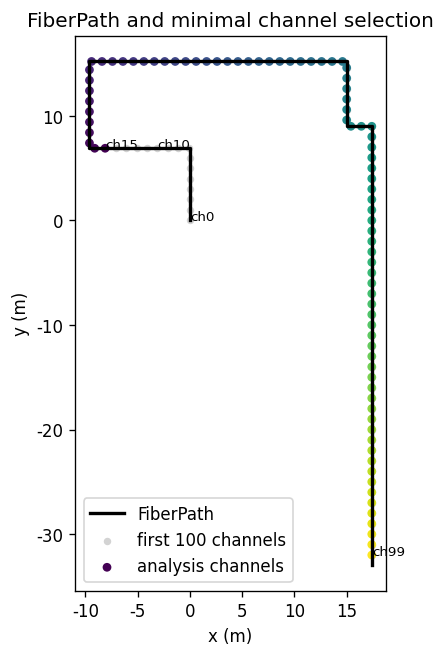

,channel_id,distance_m,x_m,y_m,within_fiber_path,used_for_analysis
0,0,0.0,0.0,0.0,True,False
1,1,1.0,0.0,1.0,True,False
2,2,2.0,0.0,2.0,True,False
3,3,3.0,0.0,3.0,True,False
4,4,4.0,0.0,4.0,True,False
5,5,5.0,0.0,5.0,True,False
6,6,6.0,0.0,6.0,True,False
7,7,7.0,-0.1,6.9,True,False
8,8,8.0,-1.1,6.9,True,False
9,9,9.0,-2.1,6.9,True,False


In [136]:
def load_fiber_path(path):
    data = np.loadtxt(path, dtype=float)
    if data.ndim != 2 or data.shape[1] < 3:
        raise ValueError("FiberPath should have at least 3 columns: x, y, z or equivalent.")
    xy = data[:, [0, 2]]
    # 当前 FiberPath 数值像厘米，自动转成米。
    scale = 0.01 if np.nanmax(np.abs(xy)) > 200 else 1.0
    return xy * scale


def channel_distance_m(channel_ids):
    return np.asarray(channel_ids, dtype=float) * CHANNEL_LENGTH_M


def channel_xy(channel_ids, fiber_xy):
    seg = np.diff(fiber_xy, axis=0)
    seg_len = np.linalg.norm(seg, axis=1)
    cum = np.concatenate([[0.0], np.cumsum(seg_len)])
    distances = channel_distance_m(channel_ids)
    xy = np.empty((len(channel_ids), 2), dtype=float)
    valid = distances <= cum[-1]
    for i, d in enumerate(np.clip(distances, 0, cum[-1])):
        j = max(0, min(np.searchsorted(cum, d, side="right") - 1, len(seg_len) - 1))
        frac = 0.0 if seg_len[j] == 0 else (d - cum[j]) / seg_len[j]
        xy[i] = fiber_xy[j] + frac * seg[j]
    return xy, valid


fiber_xy = load_fiber_path(FIBER_PATH_FILE)
all_channel_ids = np.arange(ACTIVE_CHANNEL_COUNT, dtype=int)
analysis_channel_ids = np.arange(ANALYSIS_START_CHANNEL, ACTIVE_CHANNEL_COUNT, dtype=int)
all_xy, all_valid = channel_xy(all_channel_ids, fiber_xy)
analysis_xy, analysis_valid = channel_xy(analysis_channel_ids, fiber_xy)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fiber_xy[:, 0], fiber_xy[:, 1], "-k", lw=2, label="FiberPath")
ax.scatter(all_xy[:, 0], all_xy[:, 1], s=12, c="lightgray", label="first 100 channels")
ax.scatter(analysis_xy[:, 0], analysis_xy[:, 1], s=18, c=analysis_channel_ids, cmap="viridis", label="analysis channels")
for c in [0, DROP_FIRST_CHANNELS, NOISY_PREFIX_CHANNELS, ACTIVE_CHANNEL_COUNT - 1]:
    if 0 <= c < ACTIVE_CHANNEL_COUNT:
        ax.text(all_xy[c, 0], all_xy[c, 1], f"ch{c}", fontsize=8)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("FiberPath and minimal channel selection")
ax.legend(loc="best")
plt.show()

channel_map = pd.DataFrame({
    "channel_id": all_channel_ids,
    "distance_m": channel_distance_m(all_channel_ids),
    "x_m": all_xy[:, 0],
    "y_m": all_xy[:, 1],
    "within_fiber_path": all_valid,
    "used_for_analysis": all_channel_ids >= ANALYSIS_START_CHANNEL,
})
channel_map.head(25)


## 2. 按名字选择 TDMS 并生成/复用 CSV

这一段只负责数据读取。约定：

- `DATA_DIR/Airtag/{NAME}.csv` 给出本人的开始/结束时间；
- `DATA_DIR/DAS/*.tdms` 是按 UTC 时间命名的 DAS 文件；
- 输出或复用 `output/name_signals/{NAME}.csv`；
- CSV 只写前 `ACTIVE_CHANNEL_COUNT = 100` 个通道。


In [137]:
TDMS_TIME_PATTERN = re.compile(r"_UTC_(\d{8}_\d{6}\.\d+)\.tdms$", re.IGNORECASE)
DATETIME_FORMATS = (
    "%Y-%m-%d  %H:%M:%S", "%Y/%m/%d  %H:%M:%S",
    "%Y-%m-%d %H:%M:%S", "%Y/%m/%d %H:%M:%S",
    "%Y-%m-%d  %H:%M:%S.%f", "%Y/%m/%d  %H:%M:%S.%f",
    "%Y-%m-%d %H:%M:%S.%f", "%Y/%m/%d %H:%M:%S.%f",
)


def parse_datetime(text):
    s = str(text).strip().replace("T", " ")
    for fmt in DATETIME_FORMATS:
        try:
            return datetime.strptime(s, fmt)
        except ValueError:
            pass
    raise ValueError(f"Unsupported datetime format: {text!r}")


def find_file_by_stem(folder, stem, suffix):
    stem = stem.lower().strip()
    matches = [p for p in Path(folder).glob(f"*{suffix}") if p.stem.lower() == stem]
    return matches[0] if matches else None


def read_airtag_start_end(csv_path, encoding="utf-8-sig"):
    first_dt = None
    last_dt = None
    with Path(csv_path).open("r", encoding=encoding, newline="") as f:
        reader = csv.reader(f)
        header = next(reader, None)
        if not header or not str(header[0]).strip().lower().startswith("datetime"):
            raise ValueError(f"Airtag CSV 第一列表头应以 datetime 开头: {csv_path}")
        for row in reader:
            if not row or not row[0].strip():
                continue
            dt = parse_datetime(row[0])
            if first_dt is None:
                first_dt = dt
            last_dt = dt
    if first_dt is None or last_dt is None:
        raise ValueError(f"Airtag CSV 没有有效 datetime 行: {csv_path}")
    return first_dt, last_dt


def parse_tdms_start(path):
    m = TDMS_TIME_PATTERN.search(Path(path).name)
    if not m:
        raise ValueError(f"Cannot parse UTC timestamp from TDMS name: {Path(path).name}")
    return datetime.strptime(m.group(1), "%Y%m%d_%H%M%S.%f")


def build_tdms_index(tdms_dir, default_duration_sec=60.0):
    files = sorted(Path(tdms_dir).glob("*.tdms"), key=lambda p: p.name)
    if not files:
        raise FileNotFoundError(f"No TDMS files found in {tdms_dir}")
    starts = sorted(((p, parse_tdms_start(p)) for p in files), key=lambda item: item[1])
    index = []
    for i, (path, start_utc) in enumerate(starts):
        end_utc = starts[i + 1][1] if i + 1 < len(starts) else start_utc + timedelta(seconds=default_duration_sec)
        index.append({"path": path, "start_utc": start_utc, "end_utc": end_utc})
    return index


def choose_overlapping_tdms(index, start_utc, end_utc):
    return [item for item in index if item["start_utc"] <= end_utc and item["end_utc"] >= start_utc]


def extraction_indices(file_start_utc, fs, n_samples, seg_start_utc, seg_end_utc):
    dt0 = (seg_start_utc - file_start_utc).total_seconds()
    dt1 = (seg_end_utc - file_start_utc).total_seconds()
    start_idx = int(math.ceil(dt0 * fs - 1e-9))
    end_exclusive = int(math.floor(dt1 * fs + 1e-9)) + 1
    start_idx = max(0, start_idx)
    end_exclusive = min(n_samples, end_exclusive)
    return start_idx, max(start_idx, end_exclusive)


def list_tdms_channels(tdms_file):
    channels = []
    for group in tdms_file.groups():
        channels.extend(group.channels())
    return channels


def write_signal_array_csv(path, data, write_header, append):
    mode = "a" if append else "w"
    with Path(path).open(mode, encoding="utf-8", newline="") as f:
        if write_header:
            f.write(",".join(f"ch_{i}" for i in range(data.shape[1])) + "\n")
        if data.size:
            fmt = "%d" if np.issubdtype(data.dtype, np.integer) else "%.10g"
            np.savetxt(f, data, delimiter=",", fmt=fmt)


def signal_csv_matches_current_channel_config(path):
    cols = list(pd.read_csv(path, nrows=0).columns)
    expected = [f"ch_{i}" for i in range(ACTIVE_CHANNEL_COUNT)]
    return len(cols) >= ACTIVE_CHANNEL_COUNT and cols[:ACTIVE_CHANNEL_COUNT] == expected


def resolve_or_extract_signal_csv(name, overwrite=False):
    name = name.lower().strip()
    out_csv = SIGNAL_OUTPUT_DIR / f"{name}.csv"
    if out_csv.exists() and not overwrite:
        if signal_csv_matches_current_channel_config(out_csv):
            print(f"[CSV] Reuse existing: {out_csv}")
            return out_csv
        raise ValueError(f"Existing CSV does not match ch_0..ch_{ACTIVE_CHANNEL_COUNT - 1}: {out_csv}")

    airtag_csv = find_file_by_stem(AIRTAG_DIR, name, ".csv")
    if airtag_csv is None:
        raise FileNotFoundError(f"No matching Airtag CSV for {name} in {AIRTAG_DIR}")

    try:
        from nptdms import TdmsFile
    except ImportError as exc:
        raise ImportError("需要 nptdms 才能从 TDMS 生成信号 CSV。") from exc

    SIGNAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    if out_csv.exists() and overwrite:
        raise FileExistsError("为避免误删旧文件，本最简 notebook 不覆盖已有 CSV；请手动换 NAME 或移走旧文件。")

    start_local, end_local = read_airtag_start_end(airtag_csv)
    offset = timedelta(hours=float(CSV_UTC_OFFSET_HOURS))
    start_utc = start_local - offset
    end_utc = end_local - offset
    overlaps = choose_overlapping_tdms(build_tdms_index(TDMS_DIR), start_utc, end_utc)
    if not overlaps:
        raise RuntimeError(f"No overlapping TDMS files for {name}: UTC {start_utc} -> {end_utc}")

    print(f"[Extract] {name}: {start_local} -> {end_local} local, matched TDMS files: {len(overlaps)}")
    total_rows = 0
    has_written = False
    for item in overlaps:
        tdms = TdmsFile.read(item["path"])
        channels = list_tdms_channels(tdms)
        if not channels:
            print(f"  [Warn] no channels in {item['path'].name}")
            continue
        n_samples = len(channels[0])
        i0, i1 = extraction_indices(item["start_utc"], DAS_FS, n_samples, start_utc, end_utc)
        if i1 <= i0:
            continue
        data = np.column_stack([np.asarray(ch[i0:i1]) for ch in channels[:ACTIVE_CHANNEL_COUNT]])
        write_signal_array_csv(out_csv, data, write_header=not has_written, append=has_written)
        has_written = True
        total_rows += data.shape[0]
        print(f"  [Use] {item['path'].name}: samples [{i0}, {i1}) -> {data.shape[0]:,} rows")

    if not has_written:
        raise RuntimeError(f"No samples were written for {name}")
    print(f"[CSV] Saved: {out_csv} | rows={total_rows:,}, channels={ACTIVE_CHANNEL_COUNT}")
    return out_csv


SIGNAL_CSV = resolve_or_extract_signal_csv(NAME, overwrite=OVERWRITE_CSV)
SIGNAL_CSV


[CSV] Reuse existing: d:\DAS2Steps\output\name_signals\aipumin.csv


WindowsPath('d:/DAS2Steps/output/name_signals/aipumin.csv')

## 3. 读取前 100 通道，并生成最简分析矩阵

这里保留两个矩阵：

- `X_RAW_ALL`: CSV 中前 100 个通道，shape 为 `(T, 100)`；
- `X_BASELINE`: 丢弃前 `ANALYSIS_START_CHANNEL` 个通道后的矩阵，不做归一化、不做带通增强。


In [138]:
def read_signal_csv(csv_path):
    header = pd.read_csv(csv_path, nrows=0)
    channel_cols = [c for c in header.columns if re.match(r"^ch_\d+$", str(c))]
    if not channel_cols:
        channel_cols = list(header.columns)
    channel_cols = channel_cols[:ACTIVE_CHANNEL_COUNT]
    df = pd.read_csv(csv_path, usecols=channel_cols)
    X = df.to_numpy(dtype=np.float32, copy=False)
    return X, channel_cols


X_RAW_ALL, channel_cols = read_signal_csv(SIGNAL_CSV)
analysis_cols = channel_cols[ANALYSIS_START_CHANNEL:ACTIVE_CHANNEL_COUNT]
X_BASELINE = X_RAW_ALL[:, ANALYSIS_START_CHANNEL:ACTIVE_CHANNEL_COUNT].copy()
analysis_channel_ids = np.arange(ANALYSIS_START_CHANNEL, ACTIVE_CHANNEL_COUNT, dtype=int)

print(f"SIGNAL_CSV: {SIGNAL_CSV}")
print(f"X_RAW_ALL:  {X_RAW_ALL.shape}  duration={X_RAW_ALL.shape[0] / DAS_FS:.2f}s")
print(f"X_BASELINE: {X_BASELINE.shape}  channels={analysis_channel_ids[0]}..{analysis_channel_ids[-1]}")


SIGNAL_CSV: d:\DAS2Steps\output\name_signals\aipumin.csv
X_RAW_ALL:  (418001, 100)  duration=209.00s
X_BASELINE: (418001, 85)  channels=15..99


## 4. 最温和预处理：可选 0.1 Hz 高通

这一步对应论文中的 high-pass above `0.1 Hz`。除此之外不做 MAD、不做 z-score、不做脚步频带增强。


In [139]:
def highpass_minimal(X, fs, cutoff_hz=0.1, order=2):
    if cutoff_hz is None or cutoff_hz <= 0:
        return X.copy()
    sos = signal.butter(order, cutoff_hz / (fs / 2.0), btype="highpass", output="sos")
    return signal.sosfiltfilt(sos, X, axis=0).astype(np.float32)


if APPLY_HIGHPASS:
    X_PROC = highpass_minimal(X_BASELINE, DAS_FS, cutoff_hz=HIGHPASS_HZ, order=HIGHPASS_ORDER)
else:
    X_PROC = X_BASELINE.copy()

print(f"X_PROC: {X_PROC.shape}; APPLY_HIGHPASS={APPLY_HIGHPASS}, HIGHPASS_HZ={HIGHPASS_HZ}")


X_PROC: (418001, 85); APPLY_HIGHPASS=True, HIGHPASS_HZ=0.1


## 5. 只画图检查，不改变数据

为了浏览完整时长，下面的 downsample 只用于显示，不写回数据。真正的数据矩阵仍然是 `X_BASELINE` 和 `X_PROC`。


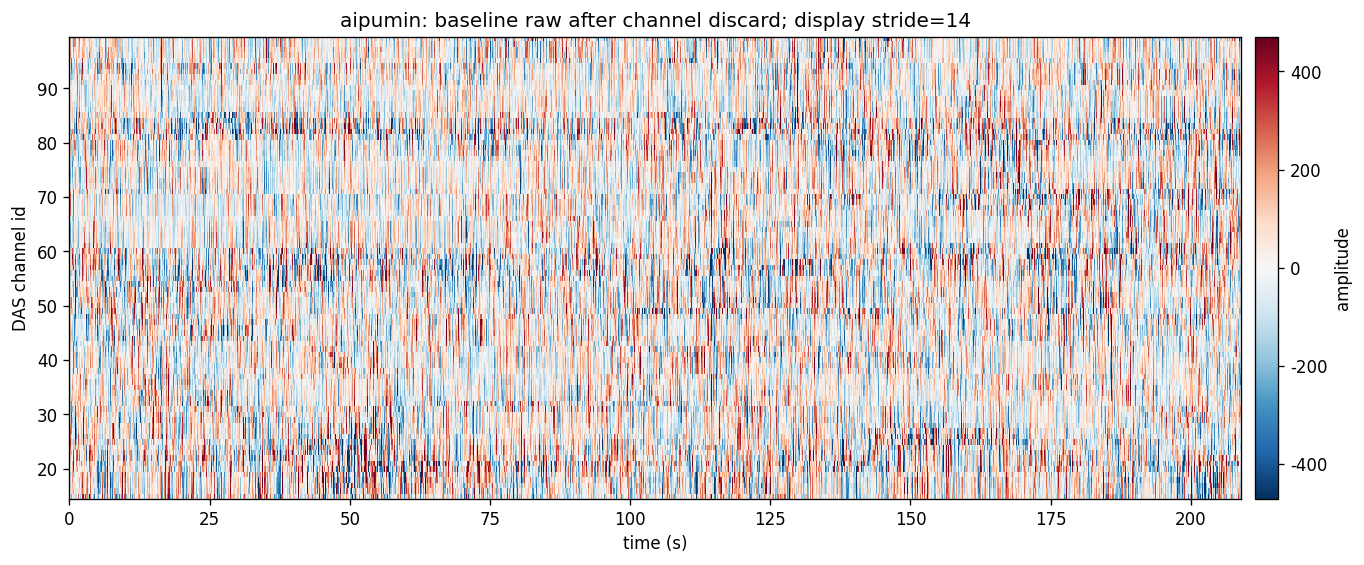

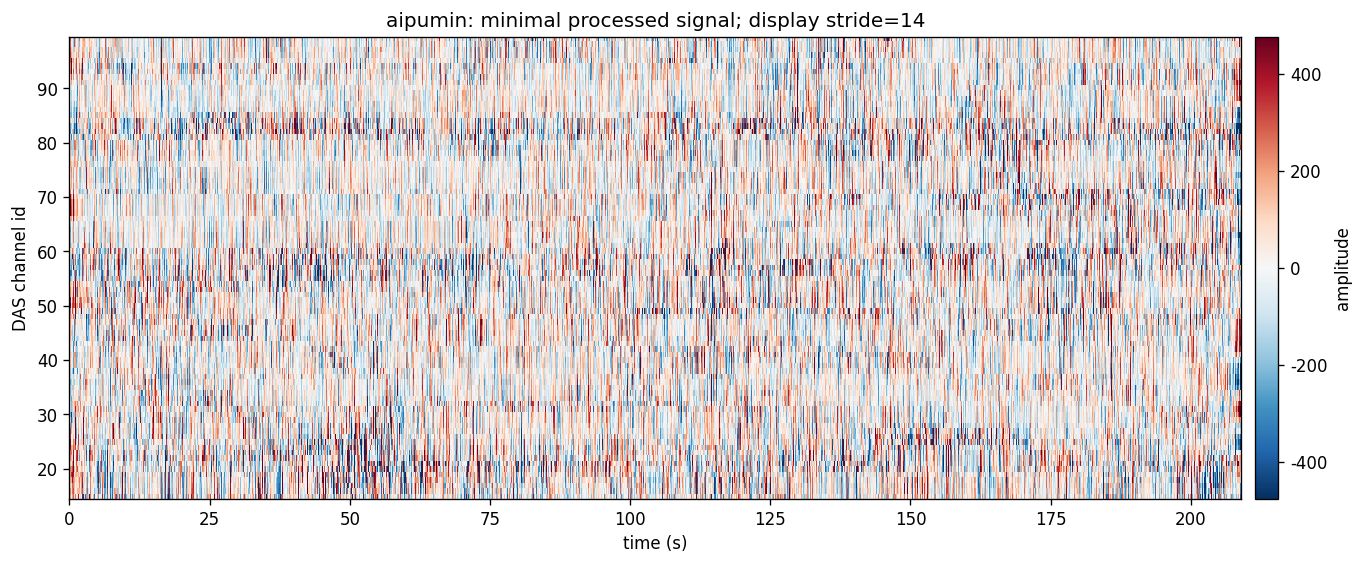

(<Figure size 1800x600 with 2 Axes>,
 <Axes: title={'center': 'aipumin: minimal processed signal; display stride=14'}, xlabel='time (s)', ylabel='DAS channel id'>)

In [140]:
def display_decimate(X, max_samples=30000):
    if max_samples is None or X.shape[0] <= max_samples:
        return X, 1
    step = int(math.ceil(X.shape[0] / max_samples))
    return X[::step], step


def plot_ct(X, channel_ids, fs, title, max_samples=30000, percentile=(1, 99)):
    X_show, step = display_decimate(X, max_samples=max_samples)
    Z = X_show.T
    v = np.nanpercentile(np.abs(Z), percentile[1])
    extent = [0, X.shape[0] / fs, channel_ids[0] - 0.5, channel_ids[-1] + 0.5]
    fig, ax = plt.subplots(figsize=(15, 5))
    im = ax.imshow(Z, aspect="auto", origin="lower", cmap="RdBu_r", extent=extent, vmin=-v, vmax=v, interpolation="nearest")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("DAS channel id")
    suffix = "" if step == 1 else f"; display stride={step}"
    ax.set_title(title + suffix)
    fig.colorbar(im, ax=ax, pad=0.01, label="amplitude")
    plt.show()
    return fig, ax


plot_ct(X_BASELINE, analysis_channel_ids, DAS_FS, f"{NAME}: baseline raw after channel discard", DISPLAY_MAX_SAMPLES)
plot_ct(X_PROC, analysis_channel_ids, DAS_FS, f"{NAME}: minimal processed signal", DISPLAY_MAX_SAMPLES)


## 6. 后续从这里开始

当前 notebook 到这里为止。后面要加检测、速度估计或 backprojection 时，应明确新增一个处理步骤，并和这个 `X_BASELINE / X_PROC` 基线对照。


## 7. 论文式降采样/滤波对照图

这一格只做图像对照，不改变前面保留的 `X_BASELINE` / `X_PROC`。

- 对照 A：`X_BASELINE -> 500 Hz resample_poly 降采样 -> 0.1 Hz high-pass`。这更接近论文的温和预处理。
- 对照 B：`X_BASELINE -> 500 Hz resample_poly 降采样 -> 0.1–30 Hz band-pass`。这只是为了看脚步相关频带是否更清楚，不作为默认基线。


X_500:          (104501, 85), fs=500.0
X_500_HP01:     (104501, 85), fs=500.0
X_500_BP01_30:  (104501, 85), fs=500.0


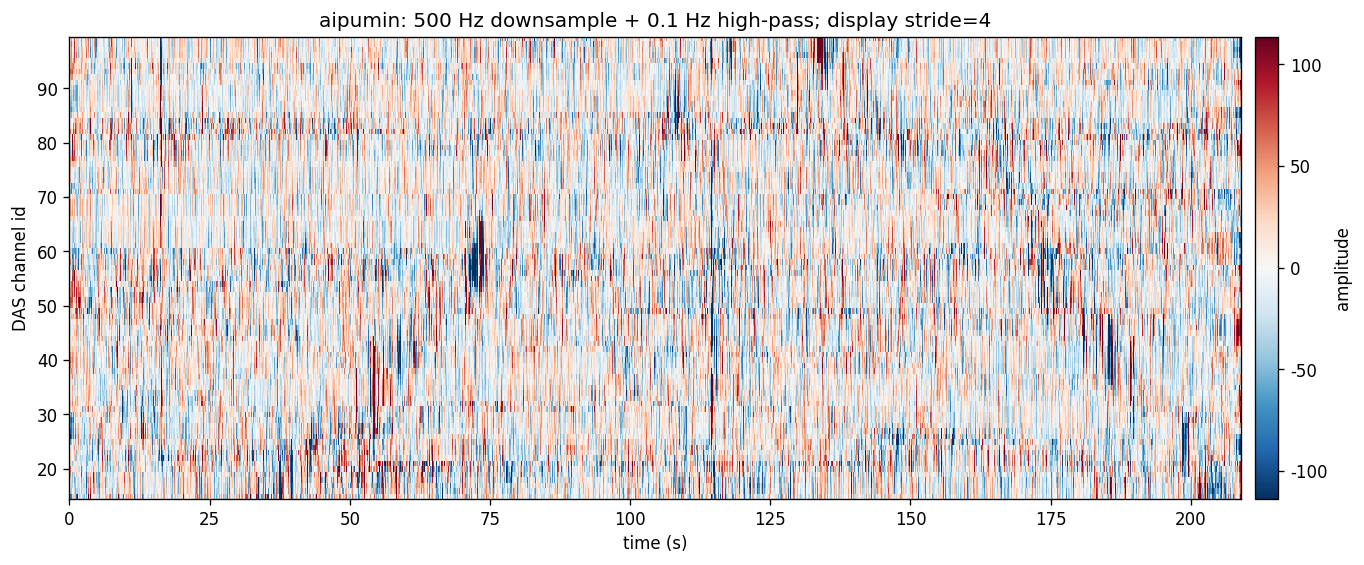

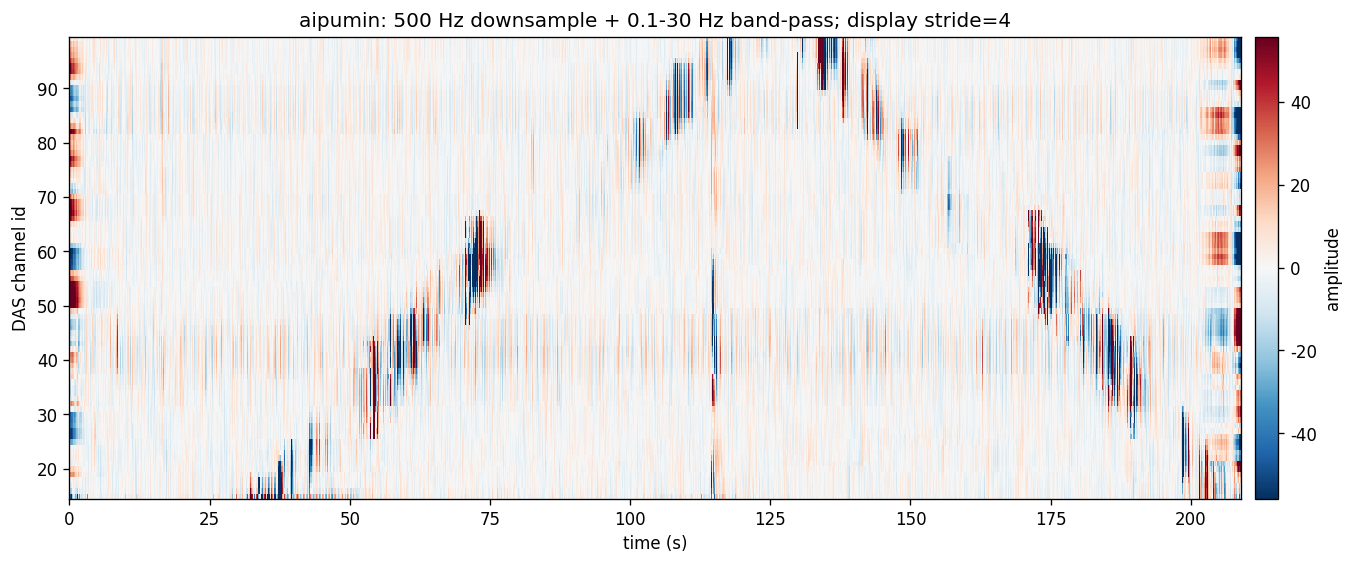

(<Figure size 1800x600 with 2 Axes>,
 <Axes: title={'center': 'aipumin: 500 Hz downsample + 0.1-30 Hz band-pass; display stride=4'}, xlabel='time (s)', ylabel='DAS channel id'>)

In [141]:
def resample_to_fs(X, fs_in, fs_out):
    """Resample along time axis. Returns X_resampled, fs_out."""
    if fs_out is None or abs(float(fs_out) - float(fs_in)) < 1e-9:
        return X.copy(), float(fs_in)
    g = math.gcd(int(round(fs_in)), int(round(fs_out)))
    up = int(round(fs_out)) // g
    down = int(round(fs_in)) // g
    Y = signal.resample_poly(X, up=up, down=down, axis=0).astype(np.float32)
    return Y, float(fs_out)


def sos_filter_minimal(X, fs, kind, cutoff, order=2):
    nyq = fs / 2.0
    if kind == "highpass":
        sos = signal.butter(order, float(cutoff) / nyq, btype="highpass", output="sos")
    elif kind == "bandpass":
        low, high = cutoff
        sos = signal.butter(order, [float(low) / nyq, float(high) / nyq], btype="bandpass", output="sos")
    else:
        raise ValueError(f"Unsupported filter kind: {kind}")
    return signal.sosfiltfilt(sos, X, axis=0).astype(np.float32)


# A. paper-like: 2000 Hz -> 500 Hz -> 0.1 Hz high-pass
X_500, FS_500 = resample_to_fs(X_BASELINE, DAS_FS, 500.0)
X_500_HP01 = sos_filter_minimal(X_500, FS_500, "highpass", 0.1, order=2)

# B. display-only bandpass: 2000 Hz -> 500 Hz -> 0.1-30 Hz band-pass
X_500_BP01_30 = sos_filter_minimal(X_500, FS_500, "bandpass", (0.1, 30.0), order=2)

print(f"X_500:          {X_500.shape}, fs={FS_500}")
print(f"X_500_HP01:     {X_500_HP01.shape}, fs={FS_500}")
print(f"X_500_BP01_30:  {X_500_BP01_30.shape}, fs={FS_500}")

plot_ct(
    X_500_HP01,
    analysis_channel_ids,
    FS_500,
    f"{NAME}: 500 Hz downsample + 0.1 Hz high-pass",
    DISPLAY_MAX_SAMPLES,
)
plot_ct(
    X_500_BP01_30,
    analysis_channel_ids,
    FS_500,
    f"{NAME}: 500 Hz downsample + 0.1-30 Hz band-pass",
    DISPLAY_MAX_SAMPLES,
)


## 8. STA/LTA 到时拾取（暂不做 GaMMA）

这一格只做文献风格的 STA/LTA 到时拾取，暂时不做 GaMMA 事件关联。

使用上一格的 `X_500_BP01_30`，也就是：

```text
X_BASELINE -> 500 Hz downsample -> 0.1–30 Hz band-pass
```

参数先按文献给出的初始值：

- STA window: `0.01 s`
- LTA window: `0.2 s`
- trigger-on: `10`
- trigger-off: `0.5`

输出：

- `STA_LTA_PICKS`: 每个 pick 的通道、时间和 STA/LTA ratio；
- 在 `0.1–30 Hz` c-t 图上叠加 pick 点。


STA/LTA picks: 1368


,channel_id,time_s,score,sample
count,1368.000000,1368.000000,1368.000000,1368.000000
mean,54.371345,115.867452,13.498884,57933.725877
std,23.692855,55.032035,4.095345,27516.017466
min,15.000000,1.608000,9.006002,804.000000
25%,36.000000,63.704000,10.245229,31852.000000
50%,51.000000,114.562000,12.195048,57281.000000
75%,74.000000,173.400000,15.640753,86700.000000
max,99.000000,207.870000,24.651119,103935.000000


,channel_id,time_s,score,sample
0,15,3.304,13.222125,1652
1,15,29.130,18.081463,14565
2,15,29.838,14.572972,14919
3,15,30.456,14.253776,15228
4,15,31.592,21.553831,15796
5,15,31.690,12.075011,15845
6,15,32.290,12.112497,16145
7,15,37.434,11.104385,18717
8,15,114.538,18.869144,57269
9,15,198.526,12.765403,99263


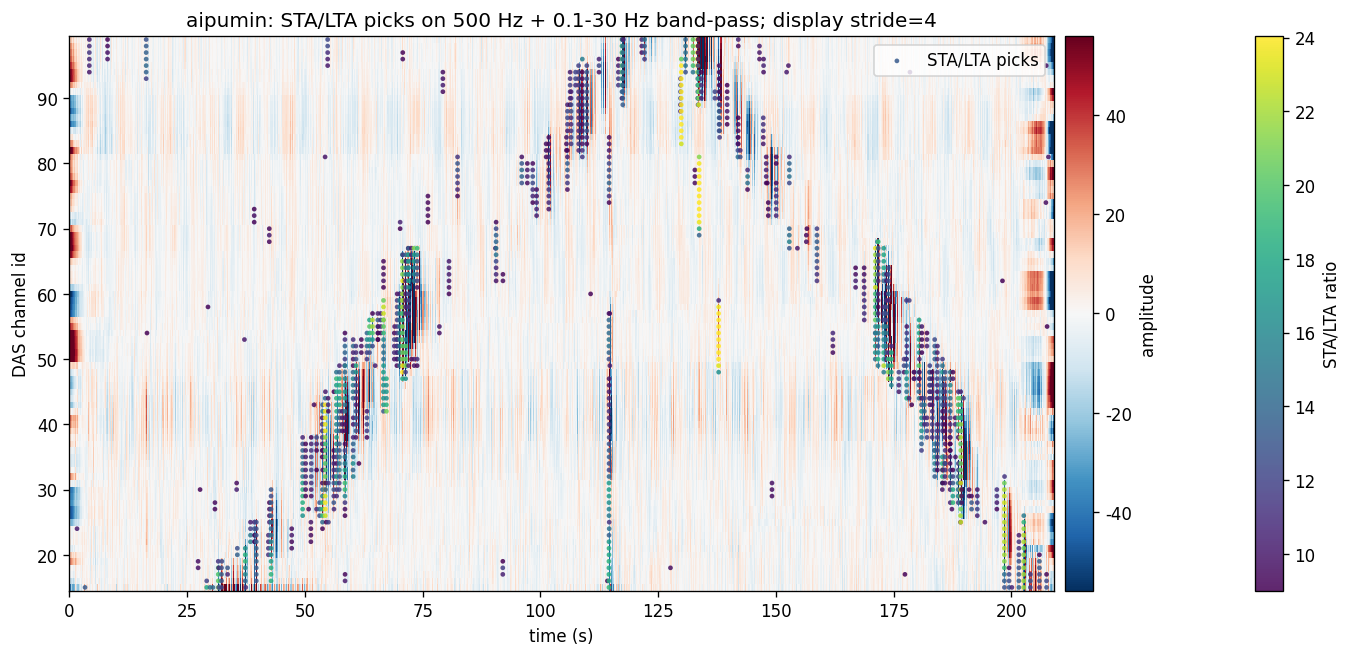

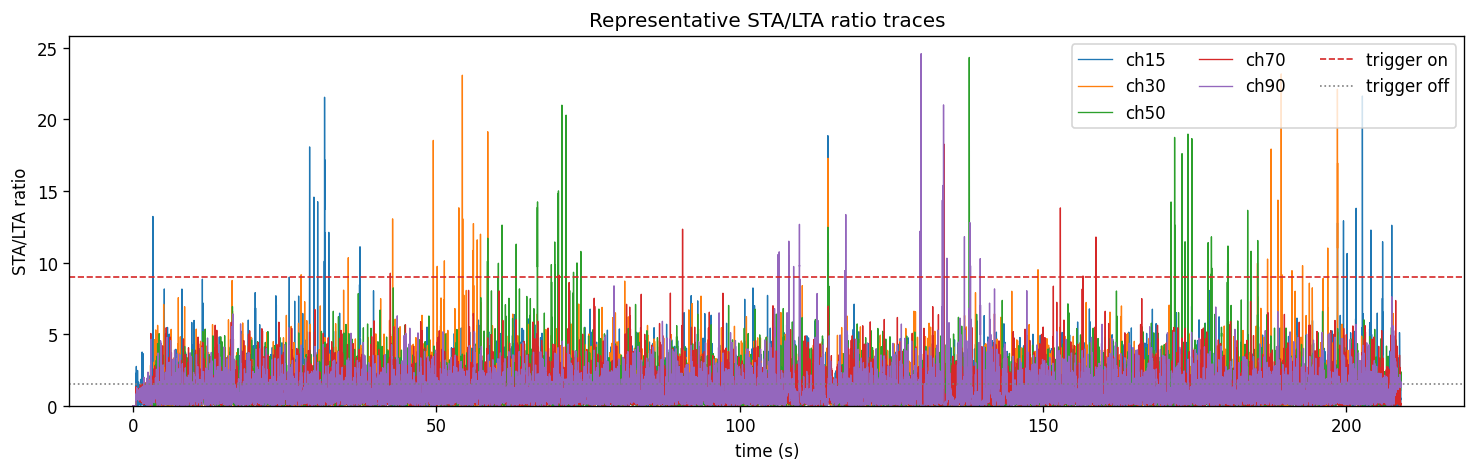

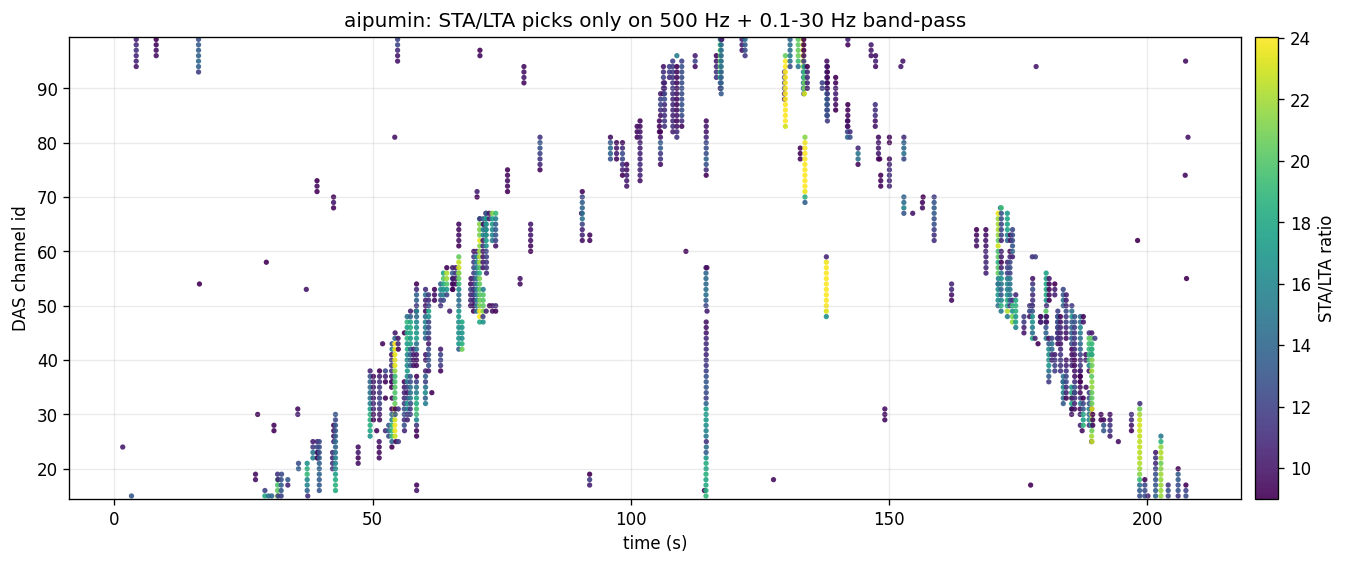

(<Figure size 1800x600 with 2 Axes>,
 <Axes: title={'center': 'aipumin: STA/LTA picks only on 500 Hz + 0.1-30 Hz band-pass'}, xlabel='time (s)', ylabel='DAS channel id'>)

In [144]:
STA_SEC = 0.02
LTA_SEC = 0.5
TRIGGER_ON = 9.0
TRIGGER_OFF = 1.5
STA_LTA_MAX_PICKS_PER_CHANNEL = None  # 调试时可设成整数，例如 200


def classic_sta_lta_ratio(y, fs, sta_sec=0.01, lta_sec=0.2):
    """Classic STA/LTA ratio on one channel."""
    y = np.asarray(y, dtype=np.float32)
    sta_n = max(1, int(round(sta_sec * fs)))
    lta_n = max(sta_n + 1, int(round(lta_sec * fs)))
    power = y.astype(np.float64) ** 2
    csum = np.concatenate([[0.0], np.cumsum(power)])

    sta = np.zeros_like(power, dtype=np.float64)
    lta = np.zeros_like(power, dtype=np.float64)
    sta[sta_n - 1:] = (csum[sta_n:] - csum[:-sta_n]) / sta_n
    lta[lta_n - 1:] = (csum[lta_n:] - csum[:-lta_n]) / lta_n
    ratio = sta / (lta + 1e-12)
    ratio[:lta_n] = 0.0
    return ratio.astype(np.float32)


def trigger_picks_from_ratio(ratio, fs, trigger_on=10.0, trigger_off=0.5):
    """Return trigger peak sample/time/score for one STA/LTA ratio trace."""
    picks = []
    active = False
    start = 0
    for i, r in enumerate(ratio):
        if (not active) and r >= trigger_on:
            active = True
            start = i
        elif active and r <= trigger_off:
            end = i
            if end > start:
                local = ratio[start:end]
                if local.size:
                    j = start + int(np.nanargmax(local))
                    picks.append({"sample": int(j), "time": float(j / fs), "score": float(ratio[j])})
            active = False
    if active:
        local = ratio[start:]
        if local.size:
            j = start + int(np.nanargmax(local))
            picks.append({"sample": int(j), "time": float(j / fs), "score": float(ratio[j])})
    return picks


def run_multichannel_sta_lta(X, fs, channel_ids):
    """Run STA/LTA for X shaped (T, C)."""
    picks = []
    ratio_preview = {}
    for j, ch in enumerate(channel_ids):
        ratio = classic_sta_lta_ratio(X[:, j], fs, sta_sec=STA_SEC, lta_sec=LTA_SEC)
        ch_picks = trigger_picks_from_ratio(ratio, fs, trigger_on=TRIGGER_ON, trigger_off=TRIGGER_OFF)
        if STA_LTA_MAX_PICKS_PER_CHANNEL is not None and len(ch_picks) > STA_LTA_MAX_PICKS_PER_CHANNEL:
            ch_picks = sorted(ch_picks, key=lambda p: p["score"], reverse=True)[:STA_LTA_MAX_PICKS_PER_CHANNEL]
            ch_picks = sorted(ch_picks, key=lambda p: p["time"])
        for p in ch_picks:
            picks.append({"channel_id": int(ch), "time_s": p["time"], "score": p["score"], "sample": p["sample"]})
        if ch in {15, 30, 50, 70, 90}:
            ratio_preview[int(ch)] = ratio
    picks_df = pd.DataFrame(picks, columns=["channel_id", "time_s", "score", "sample"])
    return picks_df, ratio_preview


STA_LTA_PICKS, STA_LTA_RATIO_PREVIEW = run_multichannel_sta_lta(X_500_BP01_30, FS_500, analysis_channel_ids)
print(f"STA/LTA picks: {len(STA_LTA_PICKS)}")
if len(STA_LTA_PICKS):
    display(STA_LTA_PICKS.describe())
    display(STA_LTA_PICKS.head(20))


def plot_sta_lta_picks_on_ct(X, fs, channel_ids, picks_df, title, max_samples=DISPLAY_MAX_SAMPLES):
    X_show, step = display_decimate(X, max_samples=max_samples)
    Z = X_show.T
    vmax = np.nanpercentile(np.abs(Z), 99)
    extent = [0, X.shape[0] / fs, channel_ids[0] - 0.5, channel_ids[-1] + 0.5]
    fig, ax = plt.subplots(figsize=(15, 6))
    im = ax.imshow(
        Z,
        aspect="auto",
        origin="lower",
        cmap="RdBu_r",
        extent=extent,
        vmin=-vmax,
        vmax=vmax,
        interpolation="nearest",
    )
    if len(picks_df):
        sc = ax.scatter(
            picks_df["time_s"],
            picks_df["channel_id"],
            c=np.clip(picks_df["score"], 0, np.nanpercentile(picks_df["score"], 98)),
            s=8,
            cmap="viridis",
            edgecolors="none",
            alpha=0.85,
            label="STA/LTA picks",
        )
        fig.colorbar(sc, ax=ax, pad=0.01, label="STA/LTA ratio")
        ax.legend(loc="upper right")
    fig.colorbar(im, ax=ax, pad=0.01, label="amplitude")
    suffix = "" if step == 1 else f"; display stride={step}"
    ax.set_title(title + suffix)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("DAS channel id")
    plt.show()
    return fig, ax


plot_sta_lta_picks_on_ct(
    X_500_BP01_30,
    FS_500,
    analysis_channel_ids,
    STA_LTA_PICKS,
    f"{NAME}: STA/LTA picks on 500 Hz + 0.1-30 Hz band-pass",
)

# 可选：查看几个代表通道的 STA/LTA ratio 曲线
if STA_LTA_RATIO_PREVIEW:
    fig, ax = plt.subplots(figsize=(15, 4))
    t_ratio = np.arange(X_500_BP01_30.shape[0]) / FS_500
    for ch, ratio in STA_LTA_RATIO_PREVIEW.items():
        ax.plot(t_ratio, ratio, lw=0.8, label=f"ch{ch}")
    ax.axhline(TRIGGER_ON, color="tab:red", ls="--", lw=1, label="trigger on")
    ax.axhline(TRIGGER_OFF, color="tab:gray", ls=":", lw=1, label="trigger off")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("STA/LTA ratio")
    ax.set_title("Representative STA/LTA ratio traces")
    ax.legend(loc="upper right", ncol=3)
    ax.set_ylim(0, min(50, max(TRIGGER_ON * 2, ax.get_ylim()[1])))
    plt.show()

def plot_sta_lta_picks_only(picks_df, title=None):
    fig, ax = plt.subplots(figsize=(15, 5))

    if len(picks_df):
        vmax = np.nanpercentile(picks_df["score"], 98)
        sc = ax.scatter(
            picks_df["time_s"],
            picks_df["channel_id"],
            c=np.clip(picks_df["score"], 0, vmax),
            s=10,
            cmap="viridis",
            edgecolors="none",
            alpha=0.9,
        )
        fig.colorbar(sc, ax=ax, pad=0.01, label="STA/LTA ratio")

    ax.set_xlabel("time (s)")
    ax.set_ylabel("DAS channel id")
    ax.set_title(title or f"{NAME}: STA/LTA picks only")
    ax.set_ylim(analysis_channel_ids[0] - 0.5, analysis_channel_ids[-1] + 0.5)
    ax.grid(True, alpha=0.25)
    plt.show()
    return fig, ax


plot_sta_lta_picks_only(
    STA_LTA_PICKS,
    title=f"{NAME}: STA/LTA picks only on 500 Hz + 0.1-30 Hz band-pass",
)
